In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN

In [ ]:
df = pd.read_csv('SAMPLE SR DATA.csv')

print('Dataset Shape:', df.shape)
print(df.head())


Dataset Shape: (6, 65)
     ATTRIBUTEDTO  BILLINGCIRCLE   CASETYPE CITYANAME         CLOSEDATE  \
0  No Fault Found            NaN  Complaint       NaN  29-06-2025 09:56   
1       TP_Router            NaN  Proactive    Tumkur  13-06-2025 12:26   
2             TNL            NaN  Complaint   Gurgaon  19-06-2025 16:27   
3             NSG            NaN  Complaint    HALDIA  19-06-2025 15:57   
4            IWAN            NaN  Complaint       NaN  19-06-2025 15:57   

  ENOCHANDOVER             IMPACT  INCIDENTID  RESOLVEDOWNER  \
0          NaN  Service Impacting         NaN         RF_EGB   
1          YES  Service Impacting         NaN   ES_ENOC_TAC1   
2          NaN  Service Impacting         NaN  SMB_TAC1_DATA   
3          NaN  Service Impacting         NaN         RF_EGB   
4          YES  Service Impacting         NaN   ES_ENOC_TAC1   

       RESOLVEDTIME  ...  AUTOMATION_RUN PEYTO_AUTOMATION  \
0  28-06-2025 09:31  ...               Y               No   
1  12-06-2025 12:03

In [ ]:
important_columns = [
    'SRNUMBER',
    'SRSUMMARY',
    'PRODUCT',
    'PLATFORM',
    'CUSTOMER_NAME',
    'ATTRIBUTEDTO',
    'X_RESOLUTION_COMMENT'
]


In [ ]:
available_columns = [col for col in important_columns if col in df.columns]

sr_df = df[available_columns].copy()

In [ ]:
# Handle Missing Values
sr_df['SRSUMMARY'] = sr_df['SRSUMMARY'].fillna('No Summary')
sr_df['X_RESOLUTION_COMMENT'] = sr_df['X_RESOLUTION_COMMENT'].fillna('No Resolution')


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

sr_df['clean_summary'] = sr_df['SRSUMMARY'].apply(clean_text)

print('Cleaned Text Samples:')
print(sr_df[['SRSUMMARY', 'clean_summary']])

Cleaned Text Samples:
                           SRSUMMARY                    clean_summary
0                         No Summary                       no summary
1  Link Down - DFGE-MYS01-ILP-RTR001  link down dfge mys01 ilp rtr001
2                         No Summary                       no summary
3                         No Summary                       no summary
4                         No Summary                       no summary
5    Link Down - BFTD-SPR127-RTR6315    link down bftd spr127 rtr6315


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate Embeddings
embeddings = model.encode(
    sr_df['clean_summary'].tolist(),
    show_progress_bar=True
)

print('Embedding Shape:', embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding Shape: (6, 384)


In [ ]:
# Apply DBSCAN Clustering
clustering_model = DBSCAN(
    eps=0.4,
    min_samples=1,
    metric='cosine'
)

clusters = clustering_model.fit_predict(embeddings)

In [ ]:
sr_df['Cluster_ID'] = clusters
print('Cluster IDs added to DataFrame.')

Cluster IDs added to DataFrame.


In [ ]:
print(sr_df[[
        'SRNUMBER',
        'SRSUMMARY',
        'PRODUCT',
        'PLATFORM',
        'Cluster_ID'
    ]]
)


   SRNUMBER                          SRSUMMARY PRODUCT PLATFORM  Cluster_ID
0  38094247                         No Summary    MPLS  RF P2MP           0
1  37984543  Link Down - DFGE-MYS01-ILP-RTR001     ISP  RF P2MP           1
2  38026485                         No Summary     ISP     FTTH           0
3  38032371                         No Summary    MPLS  RF P2MP           0
4  38030470                         No Summary    MPLS  RF P2MP           0
5  38054729    Link Down - BFTD-SPR127-RTR6315    MPLS  RF P2MP           2



================ Clustered SR Records ================


================ Repeat Pattern Frequency ================

   Cluster_ID  Frequency
0           0          4
1           1          1
2           2          1

================ Product-Level Insights ================

  PRODUCT  SR_Count
1    MPLS         4
0     ISP         2

================ Platform-Level Insights ================

  PLATFORM  SR_Count
1  RF P2MP         5
0     FTTH         1

================ Customer-Level Insights ================

                                       CUSTOMER_NAME  SR_Count
0                            ASHOKA BUILDCON LIMITED         1
1                              BAJAJ FINANCE LIMITED         1
2  FIS GLOBAL BUSINESS SOLUTIONS INDIA PRIVATE LI...         1
3                LIFE INSURANCE CORPORATION OF INDIA         1
4                      THE SOUTH INDIAN BANK LIMITED         1
5                      XPLUSD EVENTS PRIVATE LIMITED         1


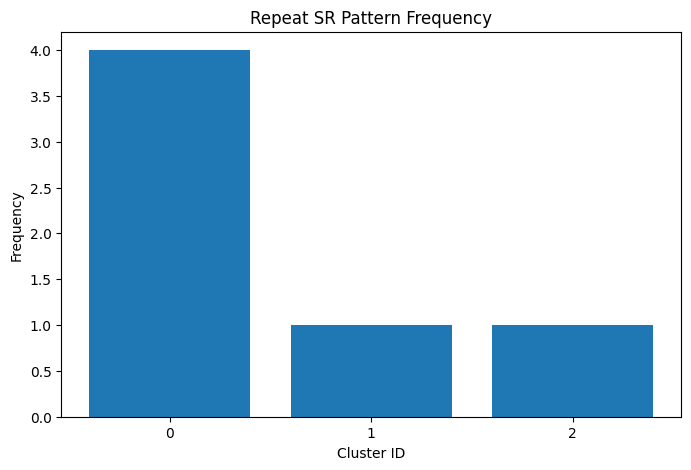

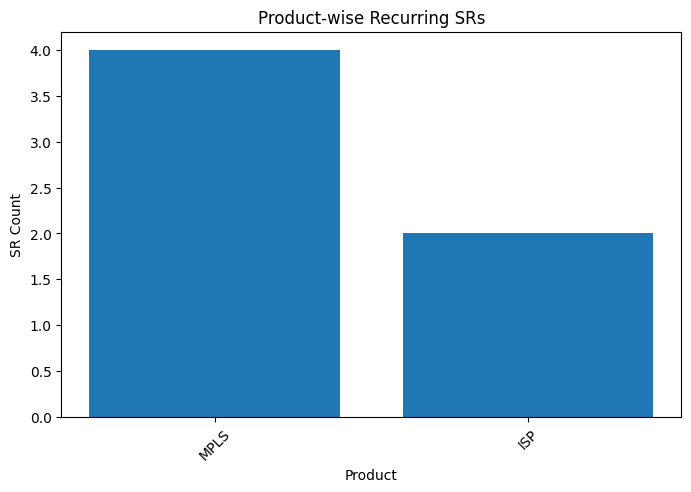


================ Final Summary Report ================

   SRNUMBER                          SRSUMMARY PRODUCT PLATFORM  \
0  38094247                         No Summary    MPLS  RF P2MP   
1  37984543  Link Down - DFGE-MYS01-ILP-RTR001     ISP  RF P2MP   
2  38026485                         No Summary     ISP     FTTH   
3  38032371                         No Summary    MPLS  RF P2MP   
4  38030470                         No Summary    MPLS  RF P2MP   
5  38054729    Link Down - BFTD-SPR127-RTR6315    MPLS  RF P2MP   

                                       CUSTOMER_NAME  Cluster_ID  
0                      THE SOUTH INDIAN BANK LIMITED           0  
1                            ASHOKA BUILDCON LIMITED           1  
2                      XPLUSD EVENTS PRIVATE LIMITED           0  
3  FIS GLOBAL BUSINESS SOLUTIONS INDIA PRIVATE LI...           0  
4                LIFE INSURANCE CORPORATION OF INDIA           0  
5                              BAJAJ FINANCE LIMITED           2  

Out

In [ ]:

print("\n================ Clustered SR Records ================\n")


cluster_frequency = (
    sr_df.groupby('Cluster_ID')
    .size()
    .reset_index(name='Frequency')
    .sort_values(by='Frequency', ascending=False)
)

print("\n================ Repeat Pattern Frequency ================\n")

print(cluster_frequency)



if 'PRODUCT' in sr_df.columns:

    product_insights = (
        sr_df.groupby('PRODUCT')
        .size()
        .reset_index(name='SR_Count')
        .sort_values(by='SR_Count', ascending=False)
    )

    print("\n================ Product-Level Insights ================\n")

    print(product_insights)



if 'PLATFORM' in sr_df.columns:

    platform_insights = (
        sr_df.groupby('PLATFORM')
        .size()
        .reset_index(name='SR_Count')
        .sort_values(by='SR_Count', ascending=False)
    )

    print("\n================ Platform-Level Insights ================\n")

    print(platform_insights)




if 'CUSTOMER_NAME' in sr_df.columns:

    customer_insights = (
        sr_df.groupby('CUSTOMER_NAME')
        .size()
        .reset_index(name='SR_Count')
        .sort_values(by='SR_Count', ascending=False)
    )

    print("\n================ Customer-Level Insights ================\n")

    print(customer_insights)


plt.figure(figsize=(8, 5))

plt.bar(
    cluster_frequency['Cluster_ID'].astype(str),
    cluster_frequency['Frequency']
)

plt.xlabel('Cluster ID')
plt.ylabel('Frequency')
plt.title('Repeat SR Pattern Frequency')

plt.show()


if 'PRODUCT' in sr_df.columns:

    plt.figure(figsize=(8, 5))

    plt.bar(
        product_insights['PRODUCT'].astype(str),
        product_insights['SR_Count']
    )

    plt.xlabel('Product')
    plt.ylabel('SR Count')
    plt.title('Product-wise Recurring SRs')

    plt.xticks(rotation=45)

    plt.show()


summary_columns = [
    col for col in [
        'SRNUMBER',
        'SRSUMMARY',
        'PRODUCT',
        'PLATFORM',
        'CUSTOMER_NAME',
        'Cluster_ID'
    ]
    if col in sr_df.columns
]

summary_report = sr_df[summary_columns]

print("\n================ Final Summary Report ================\n")

print(summary_report)


summary_report.to_csv(
    'SR_Repeat_Pattern_Output.csv',
    index=False
)

print("\nOutput CSV Saved Successfully")
print("File Name: SR_Repeat_Pattern_Output.csv")


print("\n================ Final Insights ================\n")

print("""
1. Similar SRs were successfully grouped using semantic embeddings.

2. Repeat issue patterns were identified using DBSCAN clustering.

3. Product/platform recurrence trends were identified.

4. Customer-level recurring issue insights were generated.

5. This approach can help telecom teams:
   - Reduce MTTR
   - Improve RCA identification
   - Enable proactive maintenance
   - Automate ticket categorization
""")